<a href="https://colab.research.google.com/github/npappin-wsu/BroadbandDataQuickstart/blob/main/Broadband_Data_Quickstart_Hour_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Broadband Data Quickstart

## Setup

In [17]:
!git clone https://github.com/npappin-wsu/BroadbandDataQuickstart.git data
!git -C data pull

fatal: destination path 'data' already exists and is not an empty directory.
Already up to date.


In [18]:
!pip install -r data/requirements.txt

Setup API Keys first

In [19]:
import os, pathlib, h3pandas, pygris
from google.colab import userdata
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
os.environ["BDC_USERNAME"] = userdata.get('bdc_email')
os.environ["BDC_API_KEY"] = userdata.get('bdc_hash')

In [20]:
import bdcdata

## Pull data

In [21]:
waData = bdcdata.availability.fixed(states=[53], technology='fixed', release=['2024-12-31'], cache=True)

INFO:bdcdata:Collecting availability...
State: [53]
DEBUG:bdcdata:State: [53]
Technology: fixed
DEBUG:bdcdata:Technology: fixed
Release: ['2024-12-31']
DEBUG:bdcdata:Release: ['2024-12-31']
State: Washington({'file_id': 1224952, 'category': 'State', 'subcategory': 'Location Coverage', 'technology_type': 'Fixed Broadband', 'technology_code': '10', 'technology_code_desc': 'Copper', 'speed_tier': None, 'state_fips': '53', 'state_name': 'Washington', 'provider_id': None, 'provider_name': None, 'file_type': 'csv', 'file_name': 'bdc_53_Copper_fixed_broadband_D24_03sep2025', 'record_count': '1102663'})), Technology: 10, Release: 2024-12-31
DEBUG:bdcdata:State: Washington({'file_id': 1224952, 'category': 'State', 'subcategory': 'Location Coverage', 'technology_type': 'Fixed Broadband', 'technology_code': '10', 'technology_code_desc': 'Copper', 'speed_tier': None, 'state_fips': '53', 'state_name': 'Washington', 'provider_id': None, 'provider_name': None, 'file_type': 'csv', 'file_name': 'bdc_53

In [22]:
waData.sample(n=20)

,frn,provider_id,brand_name,location_id,technology,max_advertised_download_speed,max_advertised_upload_speed,low_latency,business_residential_code,state_usps,block_geoid,h3_res8_id
5434057,0004963088,290111,Viasat Inc,1566638709,60,100,4,False,B,WA,530610519264004,8828d54d0dfffff
8923701,0012369286,130627,HughesNet,1337110794,60,100,5,False,X,WA,530610527102000,8828d0a0ebfffff
1955045,0003768165,130317,Xfinity,1330356214,40,2000,300,True,X,WA,530530733021007,8828d5da31fffff
2665638,0025646373,130235,Spectrum,1305912453,40,1000,35,True,R,WA,530770016025027,882889b91bfffff
6480313,0004963088,290111,Viasat Inc,1342633242,60,150,3,False,R,WA,530630032002007,8812db771bfffff
18327177,0007117237,370088,PocketiNet,1109886051,71,200,50,True,X,WA,530719206004005,882888c009fffff
5481806,0012369286,130627,HughesNet,1366760978,60,100,5,False,X,WA,530330256011000,8828d55321fffff
18535287,0006945950,130403,T-Mobile,1288943682,71,0,0,True,X,WA,530750002013021,88288ac58bfffff
15933140,0016912354,250003,360 Communications LLC,1109893642,70,25,10,True,X,WA,530719202002132,882888c2abfffff
2350844,0003768165,130317,Xfinity,1310101290,40,1200,35,True,X,WA,530730008053015,8828d14e3dfffff


In [23]:
waData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19853226 entries, 0 to 19853225
Data columns (total 12 columns):
 #   Column                         Dtype          
---  ------                         -----          
 0   frn                            object         
 1   provider_id                    UInt32         
 2   brand_name                     object         
 3   location_id                    UInt32         
 4   technology                     UInt16         
 5   max_advertised_download_speed  UInt32         
 6   max_advertised_upload_speed    UInt32         
 7   low_latency                    boolean        
 8   business_residential_code      string[pyarrow]
 9   state_usps                     category       
 10  block_geoid                    object         
 11  h3_res8_id                     object         
dtypes: UInt16(1), UInt32(4), boolean(1), category(1), object(4), string[pyarrow](1)
memory usage: 1.2+ GB


In [24]:
locationLookup = waData[['location_id', 'block_geoid', 'h3_res8_id']].drop_duplicates(ignore_index=True)

In [25]:
locationLookup

,location_id,block_geoid,h3_res8_id
0,1027407142,530519705001008,8812db8c59fffff
1,1121311109,530179508002000,8828d68111fffff
2,1122544844,530199702002003,8812da8343fffff
3,1296237355,530079604001044,8828d60c6dfffff
4,1296248370,530299710001051,8828d1d5d1fffff
...,...,...,...
2566302,1564174977,530079603021002,8828d6081bfffff
2566303,1564299037,530459604031000,8828d51231fffff
2566304,1342737372,530630104032044,8812db701dfffff
2566305,1342746597,530630112024002,8812db0cdbfffff


## Census Data

In [51]:
waBlocks = pygris.blocks(state='53', cache=True)
waBlockGroups = pygris.block_groups(state='53', cache=True)
waTracts = pygris.tracts(state='53', cache=True)
waCounties = pygris.counties(state='53', cache=True)
waState = pygris.states(cache=True)
waState = waState[waState.NAME == 'Washington']

Using the default year of 2024
Using the default year of 2024
Using the default year of 2024
Using the default year of 2024
Using the default year of 2024


<Axes: >

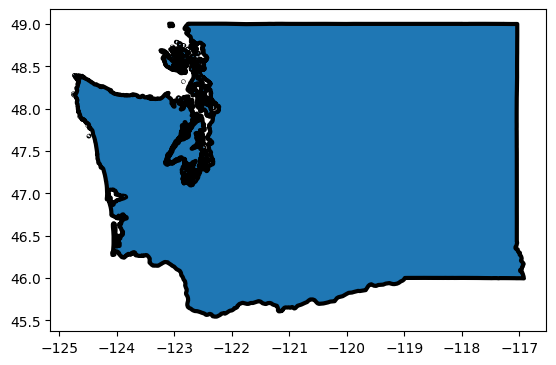

In [52]:
waState.plot(edgecolor='black', lw=3)

<Axes: >

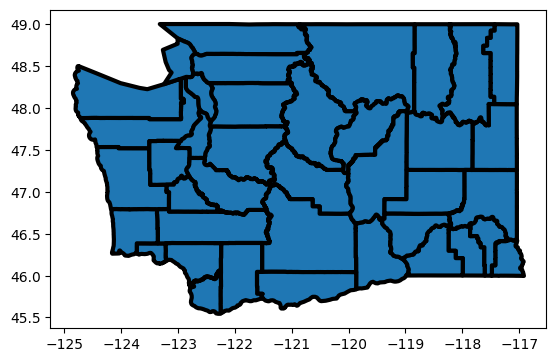

In [57]:
waCounties.plot(edgecolor='black', lw=3)

In [58]:
waCounties

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
1,53,069,01513275,53069,0500000US53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980773,61564428,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
172,53,041,01531927,53041,0500000US53041,Lewis,Lewis County,06,H1,G4020,500,16500,None,A,6223175360,86929743,+46.5800714,-122.3774443,"POLYGON ((-122.93223 46.38741, -122.93257 46.3..."
874,53,031,01531936,53031,0500000US53031,Jefferson,Jefferson County,06,H1,G4020,None,39040,None,A,4671633806,994992501,+47.8057075,-123.5270572,"POLYGON ((-122.95296 48.2698, -122.95274 48.29..."
1158,53,013,01513273,53013,0500000US53013,Columbia,Columbia County,06,H1,G4020,None,None,None,A,2249624762,12561759,+46.2928505,-117.9116345,"POLYGON ((-118.24264 46.55975, -118.24262 46.5..."
1198,53,037,01531926,53037,0500000US53037,Kittitas,Kittitas County,06,H1,G4020,None,21260,None,A,5949957158,92507199,+47.1244411,-120.6767092,"POLYGON ((-120.00214 46.99732, -120.00193 46.9..."
1292,53,061,01529222,53061,0500000US53061,Snohomish,Snohomish County,06,H1,G4020,500,42660,21794,A,5404047763,282924412,+48.0549130,-121.7650375,"POLYGON ((-122.4586 48.2977, -122.45201 48.297..."
1301,53,077,01531929,53077,0500000US53077,Yakima,Yakima County,06,H1,G4020,None,49420,None,A,11122734358,41188783,+46.4565581,-120.7401446,"POLYGON ((-120.33107 46.04149, -120.34025 46.0..."
1337,53,047,01531928,53047,0500000US53047,Okanogan,Okanogan County,06,H1,G4020,None,None,None,A,13639376693,120435134,+48.5484533,-119.7422347,"POLYGON ((-118.86953 48.48188, -118.86952 48.4..."
1338,53,063,01529225,53063,0500000US53063,Spokane,Spokane County,06,H1,G4020,518,44060,None,A,4569319088,43407377,+47.6203752,-117.4033714,"POLYGON ((-117.04183 47.73586, -117.04182 47.7..."
1344,53,029,01513272,53029,0500000US53029,Island,Island County,06,H1,G4020,500,36020,None,A,539943912,799920796,+48.1585538,-122.6706492,"POLYGON ((-122.86308 48.37036, -122.86287 48.3..."


<Axes: >

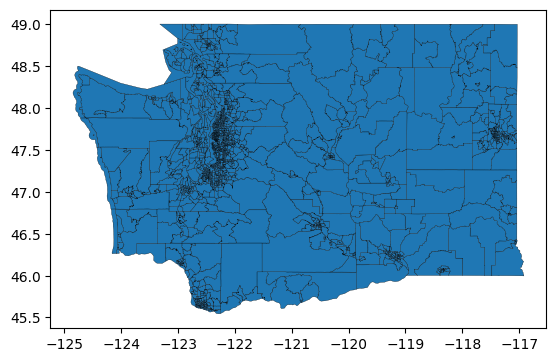

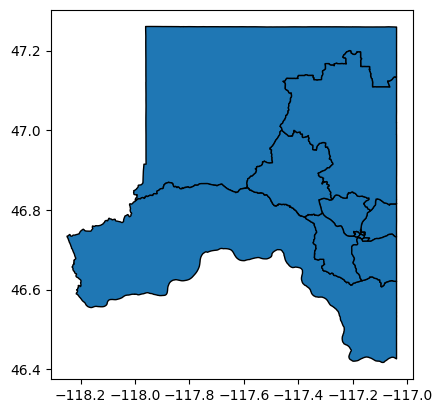

In [71]:
waTracts.plot(edgecolor='black', lw=.2)
waTracts[waTracts.COUNTYFP == '075'].plot(edgecolor='black', lw=1)

<Axes: >

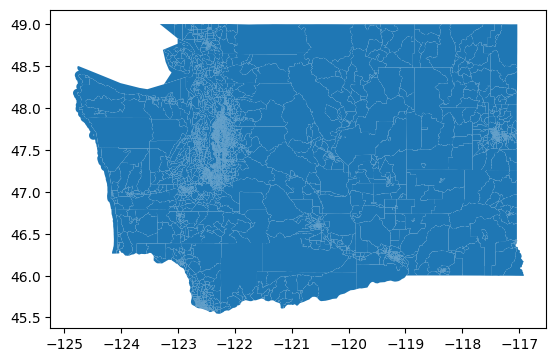

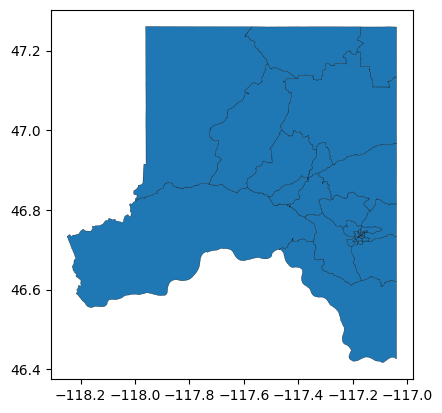

In [64]:
waBlockGroups.plot()
waBlockGroups[waBlockGroups.COUNTYFP == '075'].plot(edgecolor='black', lw=.2)

<Axes: >

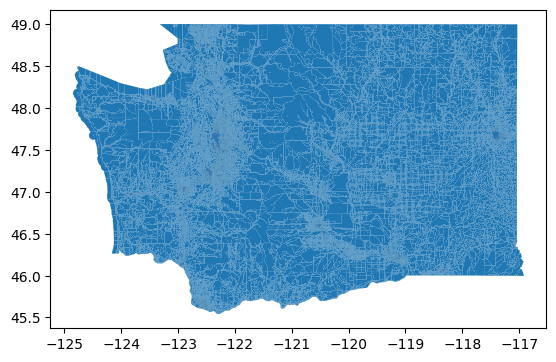

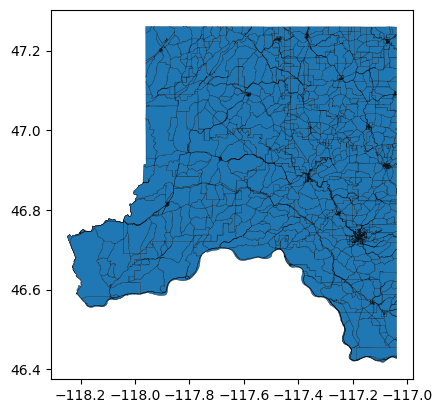

In [69]:
waBlocks.plot()
waBlocks[waBlocks.COUNTYFP20 == '075'].plot(edgecolor='black', lw=.2)

In [66]:
waBlocks.sample(n=100)

,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry
90248,53,067,012710,1006,530670127101006,1000000US530670127101006,Block1006,G5040,R,None,S,191233,0,+46.8311321,-122.9735265,6,13,"POLYGON ((-122.97811 46.83068, -122.978 46.830..."
92713,53,063,004500,2001,530630045002001,1000000US530630045002001,Block2001,G5040,U,83764,S,32460,0,+47.6384608,-117.3967043,25,55,"POLYGON ((-117.39854 47.63912, -117.39853 47.6..."
17786,53,025,011300,1070,530250113001070,1000000US530250113001070,Block1070,G5040,R,None,S,920312,0,+46.9752789,-119.2569794,0,0,"POLYGON ((-119.26584 46.98173, -119.2653 46.98..."
19691,53,073,010101,2120,530730101012120,1000000US530730101012120,Block2120,G5040,R,None,S,54392,0,+48.8318086,-122.2363776,0,0,"POLYGON ((-122.23934 48.83189, -122.23935 48.8..."
82878,53,033,021400,1023,530330214001023,1000000US530330214001023,Block1023,G5040,U,80389,S,9173,0,+47.7506541,-122.2802904,6,22,"POLYGON ((-122.281 47.75061, -122.27992 47.751..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68201,53,041,971100,1039,530419711001039,1000000US530419711001039,Block1039,G5040,R,None,S,333554,0,+46.6498083,-122.7801288,12,38,"POLYGON ((-122.78539 46.6401, -122.78529 46.64..."
143658,53,033,030700,2001,530330307002001,1000000US530330307002001,Block2001,G5040,U,80389,S,22455,0,+47.3015308,-122.2270010,11,46,"POLYGON ((-122.22867 47.30192, -122.22698 47.3..."
46240,53,007,960301,1026,530079603011026,1000000US530079603011026,Block1026,G5040,U,15913,S,56812,0,+47.8503226,-120.1176586,17,32,"POLYGON ((-120.12098 47.85155, -120.11983 47.8..."
116288,53,005,011801,2025,530050118012025,1000000US530050118012025,Block2025,G5040,R,None,S,487792,0,+46.2419682,-119.6717883,12,37,"POLYGON ((-119.6814 46.24209, -119.6811 46.242..."


In [29]:
blockLocations = locationLookup.block_geoid.value_counts().reset_index()

In [30]:
blockLocations

,block_geoid,count
0,530110401014003,1178
1,530530731291006,943
2,530730104112000,781
3,530050108112000,713
4,530530724063000,632
...,...,...
121440,530330328003195,1
121441,530210208023033,1
121442,530750007001333,1
121443,530399501031013,1


In [31]:
blockLocations = blockLocations.merge(waBlocks, how='left', left_on='block_geoid', right_on='GEOID20')


In [32]:
blockLocations

,block_geoid,count,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry
0,530110401014003,1178,53,011,040101,4003,530110401014003,1000000US530110401014003,Block4003,G5040,R,None,S,24304171,24397,+45.9451345,-122.4043196,190,477,"POLYGON ((-122.4525 45.96029, -122.45244 45.96..."
1,530530731291006,943,53,053,073129,1006,530530731291006,1000000US530530731291006,Block1006,G5040,U,80389,S,743705,0,+47.0856363,-122.2802616,347,1112,"POLYGON ((-122.29039 47.08723, -122.29024 47.0..."
2,530730104112000,781,53,073,010411,2000,530730104112000,1000000US530730104112000,Block2000,G5040,U,07759,S,1351585,0,+48.9287649,-122.7358518,438,459,"POLYGON ((-122.74543 48.92864, -122.74454 48.9..."
3,530050108112000,713,53,005,010811,2000,530050108112000,1000000US530050108112000,Block2000,G5040,R,None,S,4496445,0,+46.2196179,-119.3240027,179,505,"POLYGON ((-119.34761 46.22571, -119.3476 46.22..."
4,530530724063000,632,53,053,072406,3000,530530724063000,1000000US530530724063000,Block3000,G5040,U,80389,S,5365774,0,+47.3034599,-122.6524294,640,1711,"POLYGON ((-122.66946 47.29903, -122.66942 47.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121440,530330328003195,1,53,033,032800,3195,530330328003195,1000000US530330328003195,Block3195,G5040,R,None,S,50416,0,+47.7136635,-121.1705034,2,0,"POLYGON ((-121.17666 47.71522, -121.17638 47.7..."
121441,530210208023033,1,53,021,020802,3033,530210208023033,1000000US530210208023033,Block3033,G5040,R,None,S,2257742,0,+46.7004070,-118.7051981,1,0,"POLYGON ((-118.7152 46.70681, -118.69431 46.70..."
121442,530750007001333,1,53,075,000700,1333,530750007001333,1000000US530750007001333,Block1333,G5040,R,None,S,1192608,0,+46.9647088,-117.2175257,1,2,"POLYGON ((-117.22399 46.9661, -117.22388 46.96..."
121443,530399501031013,1,53,039,950103,1013,530399501031013,1000000US530399501031013,Block1013,G5040,R,None,S,120700,0,+45.8915524,-120.7264971,1,10,"POLYGON ((-120.73074 45.89053, -120.7305 45.89..."


In [33]:
blockLocations = gpd.GeoDataFrame(blockLocations)

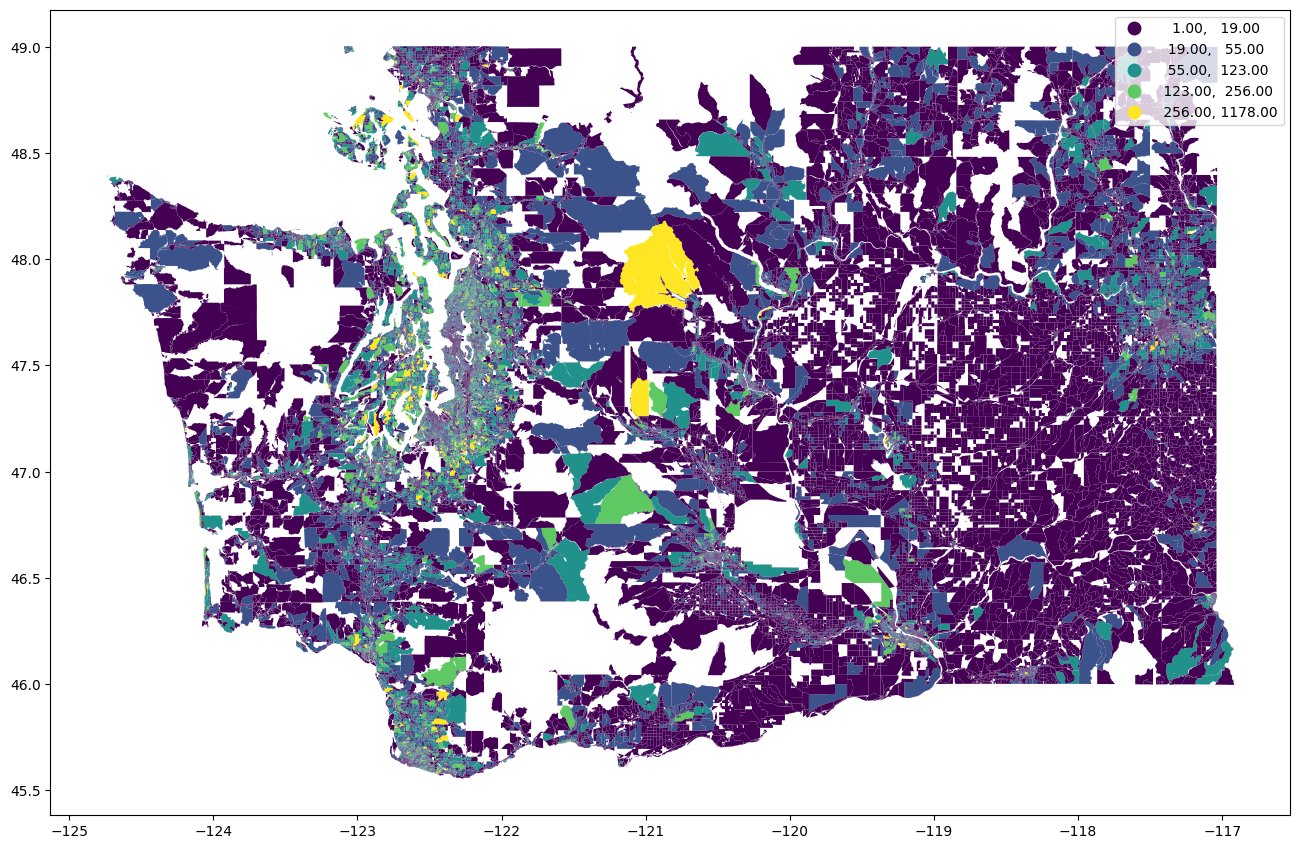

In [34]:
fig, ax2 = plt.subplots(figsize=(16, 16))
blockLocations.plot(ax = ax2, column='count', scheme='FisherJenks', legend=True)
fig.show()

In [35]:
plt.close(fig)

In [36]:
blockLocations['countPopNorm'] = blockLocations['count'] / blockLocations.POP20.replace(0, np.nan)
blockLocations['countHousingNorm'] = blockLocations['count'] / blockLocations.HOUSING20.replace(0, np.nan)

In [37]:
blockLocations.sample(n=5)

,block_geoid,count,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,...,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry,countPopNorm,countHousingNorm
42645,530399503011043,17,53,039,950301,1043,530399503011043,1000000US530399503011043,Block1043,G5040,...,S,21898,0,+45.7282657,-121.4879249,17,24,"POLYGON ((-121.48922 45.72877, -121.4867 45.72...",0.708333,1.000000
10724,530210206053027,51,53,021,020605,3027,530210206053027,1000000US530210206053027,Block3027,G5040,...,S,47699,0,+46.2647383,-119.1679080,50,174,"POLYGON ((-119.16852 46.26234, -119.16845 46.2...",0.293103,1.020000
78624,530399503024058,7,53,039,950302,4058,530399503024058,1000000US530399503024058,Block4058,G5040,...,S,7480,0,+45.7157510,-121.4635710,8,16,"POLYGON ((-121.46427 45.71574, -121.46426 45.7...",0.437500,0.875000
71613,530659501023115,9,53,065,950102,3115,530659501023115,1000000US530659501023115,Block3115,G5040,...,S,179636,0,+48.6179080,-118.1036005,9,22,"POLYGON ((-118.10817 48.62022, -118.10795 48.6...",0.409091,1.000000
5573,530090007003018,79,53,009,000700,3018,530090007003018,1000000US530090007003018,Block3018,G5040,...,S,898950,0,+48.1093370,-123.4804999,92,158,"POLYGON ((-123.48654 48.1049, -123.48654 48.10...",0.500000,0.858696


In [38]:
int(blockLocations.shape[0]*.1)

12144

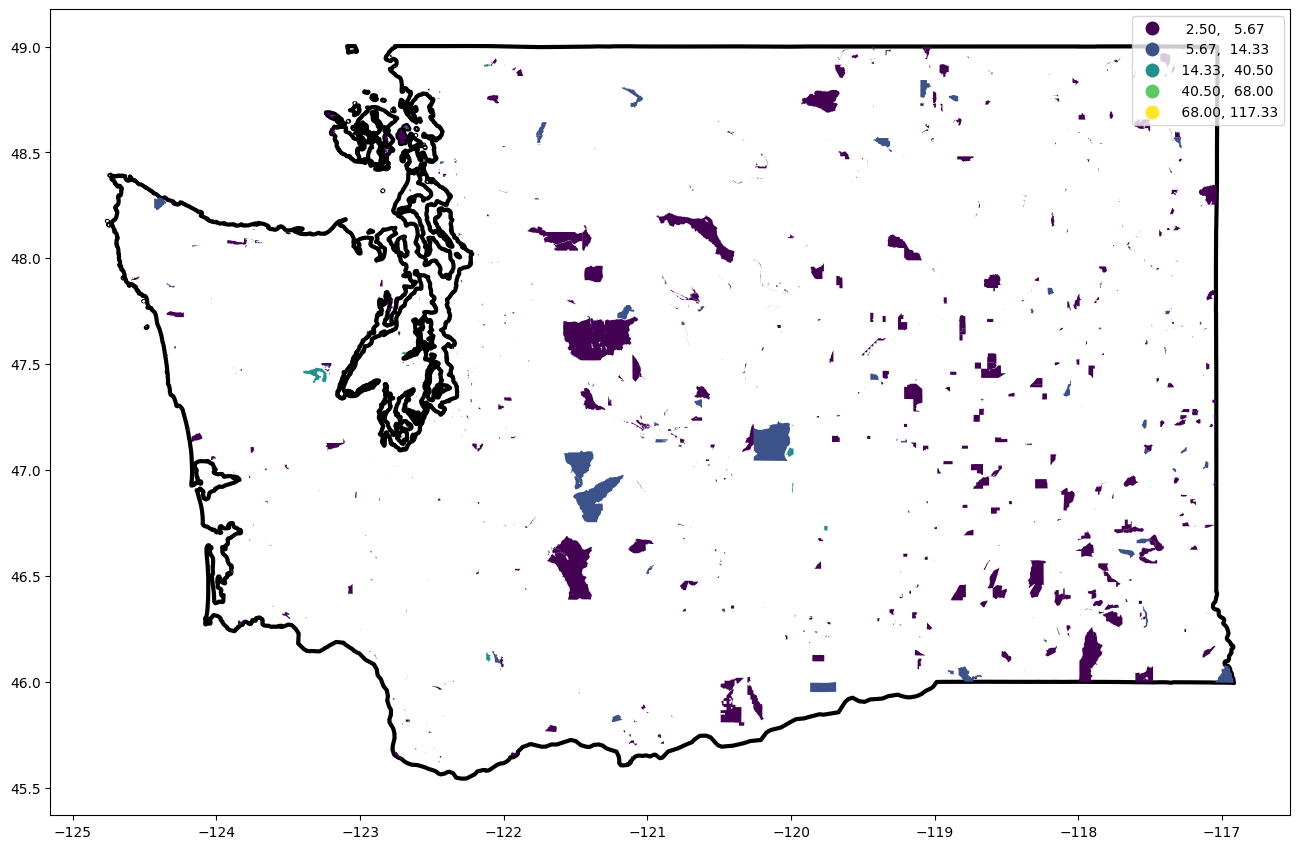

In [39]:
fig, ax2 = plt.subplots(figsize=(16, 16))
num = int(blockLocations.shape[0]*.01)
waState.plot(ax=ax2, facecolor='none', edgecolor='black', lw=3)
blockLocations.nlargest(num, 'countPopNorm').plot(ax = ax2, column='countPopNorm', scheme='FisherJenks', legend=True)
fig.show()

In [40]:
plt.close(fig)

<Axes: >

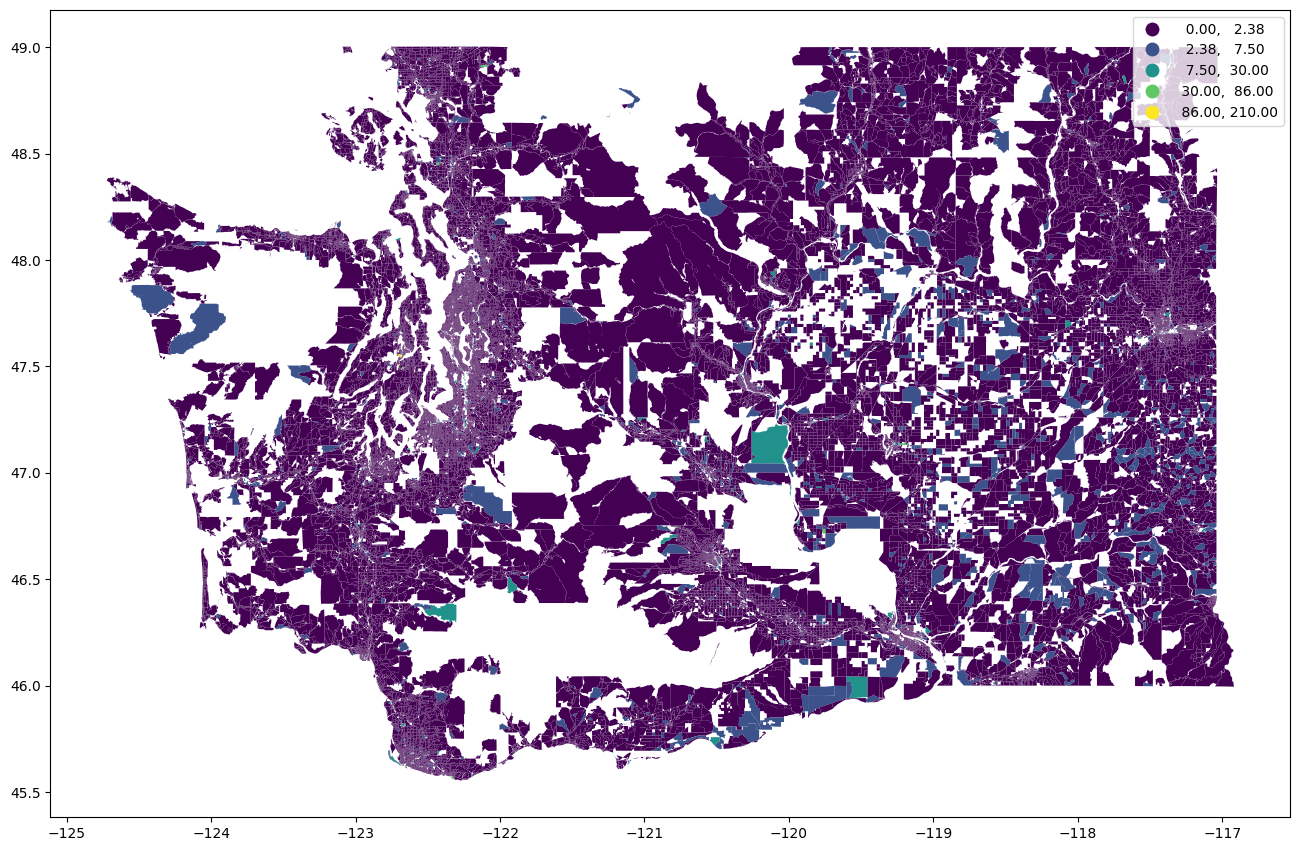

In [42]:
fig, ax2 = plt.subplots(figsize=(16, 16))
blockLocations.plot(ax = ax2, column='countHousingNorm', scheme='FisherJenks', legend=True)

## H3 Data

In [ ]:
fpLocations = pd.read_csv(pathlib.Path('data', 'fp_locations.csv'))

In [ ]:
fpLocations.drop_duplicates()

In [ ]:
locations = fpLocations[['location_id', 'technology']].merge(locationLookup, how='left', on='location_id')

In [ ]:
locations.shape

In [ ]:
locations.drop_duplicates()

In [ ]:
pivoted = locations[['h3_res8_id', 'technology', 'location_id']].pivot_table(index='h3_res8_id', columns='technology', values='location_id', aggfunc='count', fill_value=0, )
pivoted.columns = pivoted.columns.astype(str)

In [ ]:
pivoted.to_excel('test.xlsx')

In [ ]:
pivoted.info()

In [ ]:
pivoted['70s'] = pivoted.loc[:, "70"] + pivoted.loc[:, "71"] + pivoted.loc[:, "72"]

In [ ]:
pivoted['max'] = pivoted[["50", "70s", "61"]].idxmax(axis=1)

In [ ]:
techHash = {
    '50': 'Fiber',
    '61': 'LEO',
    '70': 'ULFW',
    '71': 'LFW',
    '72': 'LBRW',
    '70s': 'Wireless'
}

In [ ]:
pivoted.rename(columns=techHash, inplace=True)

In [ ]:
pivoted

In [ ]:
gpd.GeoDataFrame(pivoted.h3.h3_to_geo_boundary()).explore(column='max', categorical=True, tiles="CartoDB dark_matter").save("h3.html")